# Évaluation & Test du modèle
#### Waste Classification — MobileNetV2

Ce notebook charge le modèle entraîné et effectue une évaluation complète sur le **test set** (données jamais vues pendant l'entraînement).

**Étapes couvertes :**
1. Chargement du modèle et vérification des classes
2. Vérification que le modèle a bien été entraîné sur toutes les classes
3. Évaluation globale (accuracy, loss)
4. Rapport de classification complet (precision, recall, F1 par classe)
5. Matrice de confusion
6. Visualisation des prédictions sur des images réelles
7. Test sur une image custom

---
## 1. Imports

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
import os

print('TensorFlow version :', tf.__version__)

TensorFlow version : 2.16.1


---
## 2. Chargement du modèle sauvegardé

In [2]:
model = load_model('../model/waste_classifier.keras')
print('✅ Modèle chargé avec succès.')
model.summary()

✅ Modèle chargé avec succès.


Model: "waste_classifier_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,752,212 (10.50 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 329,486 (1.26 MB)

---
## 3. Vérification des classes — le modèle a-t-il vu toutes les classes ?

On charge les `class_names` sauvegardés pendant le training et on vérifie :
- que le nombre de classes correspond à la couche de sortie du modèle (`Dense(6)`)
- que les 6 classes du dataset sont toutes présentes

In [4]:
# ── Charger les class_names sauvegardés ────────────────────────────
class_names = np.load('../model/class_names.npy', allow_pickle=True).tolist()

# ── Classes attendues du dataset ────────────────────────────────────
EXPECTED_CLASSES = sorted(['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'])

print('Classes enregistrées pendant le training :')
for i, c in enumerate(class_names):
    print(f'  {i} → {c}')

print()

# ── Vérification 1 : nombre de classes vs couche de sortie ──────────
output_units = model.layers[-1].get_config()['units']
print(f'Couche Dense de sortie : {output_units} neurones')
print(f'Nombre de classes chargées : {len(class_names)}')

if output_units == len(class_names):
    print('✅ Cohérence OK : Dense(6) correspond aux 6 classes.')
else:
    print('❌ ERREUR : incohérence entre la couche de sortie et les classes !')

print()

# ── Vérification 2 : toutes les classes du dataset sont présentes ────
missing = set(EXPECTED_CLASSES) - set(class_names)
extra   = set(class_names) - set(EXPECTED_CLASSES)

if not missing and not extra:
    print('✅ Toutes les 6 classes du dataset sont présentes :')
    for c in EXPECTED_CLASSES:
        print(f'   ✔ {c}')
else:
    if missing:
        print(f'❌ Classes manquantes : {missing}')
    if extra:
        print(f'⚠️  Classes inattendues : {extra}')

Classes enregistrées pendant le training :
  0 → cardboard
  1 → glass
  2 → metal
  3 → paper
  4 → plastic
  5 → trash

Couche Dense de sortie : 6 neurones
Nombre de classes chargées : 6
✅ Cohérence OK : Dense(6) correspond aux 6 classes.

✅ Toutes les 6 classes du dataset sont présentes :
   ✔ cardboard
   ✔ glass
   ✔ metal
   ✔ paper
   ✔ plastic
   ✔ trash


---
## 4. Reconstruction du test set

On recharge le dataset avec les **mêmes paramètres** que pendant le training (`seed=42`) pour obtenir exactement le même split.
`shuffle=False` est crucial pour garantir que l'ordre des images correspond aux labels sauvegardés.

In [5]:
dataset_path = '../dataset'
IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 32
SEED         = 42

# ── Recharger le dataset complet (même config que le training) ───────
full_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# ── Reconstruire exactement le même split 70/15/15 ───────────────────
total_batches = len(full_dataset)
train_size    = int(0.70 * total_batches)
val_size      = int(0.15 * total_batches)

test_dataset = (
    full_dataset
    .skip(train_size + val_size)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

print(f'Total batches  : {total_batches}')
print(f'Test batches   : {len(test_dataset)}')
print(f'Approx. images de test : ~{len(test_dataset) * BATCH_SIZE}')
print('✅ Test set reconstruit.')

Found 2525 files belonging to 6 classes.
Total batches  : 79
Test batches   : 13
Approx. images de test : ~416
✅ Test set reconstruit.


---
## 5. Évaluation globale : Accuracy & Loss

`model.evaluate()` calcule l'accuracy et la loss sur **toutes** les images du test set en un seul appel.

In [6]:
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)

print()
print('═' * 40)
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_accuracy * 100:.2f}%')
print('═' * 40)

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 399ms/step - accuracy: 0.8450 - loss: 0.4885

════════════════════════════════════════
  Test Loss     : 0.4885
  Test Accuracy : 84.50%
════════════════════════════════════════


---
## 6. Prédictions sur le test set

On charge les `true_classes` et `predicted_classes` sauvegardés à la fin du training.
Si les fichiers `.npy` n'existent pas encore (premier run), on les recalcule ici.

In [7]:
npy_true = '../model/true_classes.npy'
npy_pred = '../model/predicted_classes.npy'

if os.path.exists(npy_true) and os.path.exists(npy_pred):
    true_classes      = np.load(npy_true)
    predicted_classes = np.load(npy_pred)
    print('✅ Prédictions chargées depuis les fichiers .npy')
else:
    print('Fichiers .npy introuvables — recalcul des prédictions...')
    predictions = model.predict(test_dataset, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = []
    for _, labels in test_dataset:
        true_classes.extend(labels.numpy())
    true_classes = np.array(true_classes)
    np.save(npy_true, true_classes)
    np.save(npy_pred, predicted_classes)
    print('✅ Prédictions calculées et sauvegardées.')

print(f'Nombre d\'images testées : {len(true_classes)}')
print(f'Classes vraies uniques     : {np.unique(true_classes)}')
print(f'Classes prédites uniques   : {np.unique(predicted_classes)}')

✅ Prédictions chargées depuis les fichiers .npy
Nombre d'images testées : 413
Classes vraies uniques     : [0 1 2 3 4 5]
Classes prédites uniques   : [0 1 2 3 4 5]


---
## 7. Vérification : le modèle prédit-il toutes les classes ?

On vérifie que le modèle ne s'est pas « bloqué » sur un sous-ensemble de classes.

In [8]:
predicted_set = set(np.unique(predicted_classes))
expected_set  = set(range(len(class_names)))

print('Classes dans le test set (vraies)    :', sorted(set(np.unique(true_classes))))
print('Classes prédites par le modèle       :', sorted(predicted_set))
print()

never_predicted = expected_set - predicted_set
if not never_predicted:
    print('✅ Le modèle prédit toutes les 6 classes.')
else:
    print('⚠️  Classes jamais prédites :')
    for idx in never_predicted:
        print(f'   {idx} → {class_names[idx]}')
    print('   → Cette classe est probablement sous-représentée dans le dataset.')

print()
print('Distribution des vraies classes dans le test set :')
for idx in range(len(class_names)):
    count = np.sum(true_classes == idx)
    bar   = '█' * (count // 3)
    print(f'  {class_names[idx]:12s} ({idx}) : {count:4d} images  {bar}')

Classes dans le test set (vraies)    : [0, 1, 2, 3, 4, 5]
Classes prédites par le modèle       : [0, 1, 2, 3, 4, 5]

✅ Le modèle prédit toutes les 6 classes.

Distribution des vraies classes dans le test set :
  cardboard    (0) :   57 images  ███████████████████
  glass        (1) :   73 images  ████████████████████████
  metal        (2) :   69 images  ███████████████████████
  paper        (3) :  106 images  ███████████████████████████████████
  plastic      (4) :   81 images  ███████████████████████████
  trash        (5) :   27 images  █████████


---
## 8. Rapport de classification complet

Pour chaque classe :
- **Precision** : parmi les images prédites comme classe X, combien sont vraiment X ?
- **Recall** : parmi toutes les images qui sont vraiment X, combien a-t-on trouvées ?
- **F1-score** : moyenne harmonique de precision et recall. C'est le vrai indicateur de performance par classe.

> Une classe avec recall faible = le modèle la reconnaît mal (la confond avec une autre).

In [9]:
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names,
    digits=3
)
print(report)

              precision    recall  f1-score   support

   cardboard      0.877     0.877     0.877        57
       glass      0.756     0.849     0.800        73
       metal      0.808     0.855     0.831        69
       paper      0.927     0.840     0.881       106
     plastic      0.843     0.864     0.854        81
       trash      0.864     0.704     0.776        27

    accuracy                          0.845       413
   macro avg      0.846     0.832     0.836       413
weighted avg      0.850     0.845     0.846       413



---
## 9. Matrice de confusion

Chaque ligne = classe réelle. Chaque colonne = classe prédite.
- La **diagonale** (en vert) = bonnes prédictions.
- Les **cases hors diagonale** = confusions entre classes.

C'est le moyen le plus rapide d'identifier quelles classes le modèle confond entre elles.

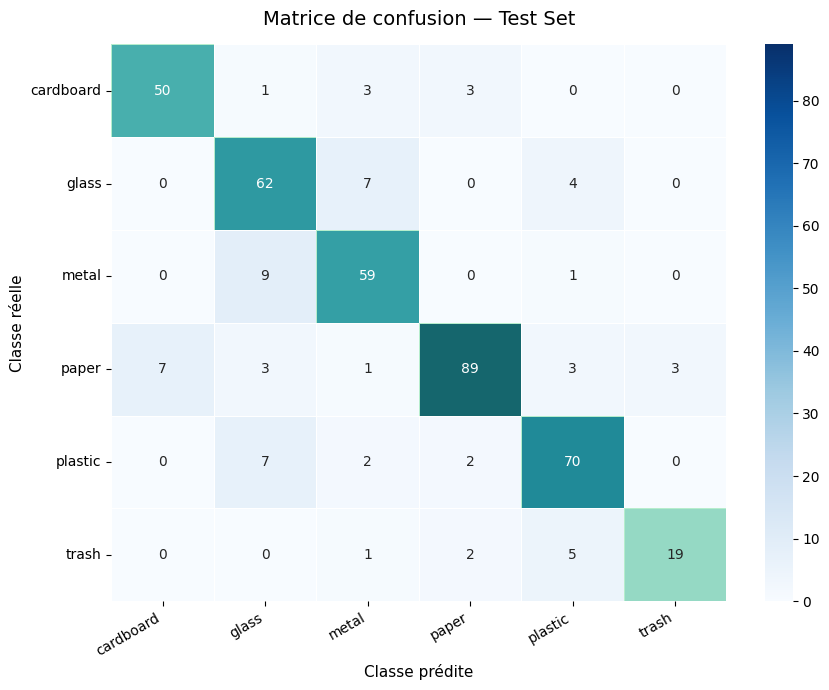

✅ Matrice sauvegardée : ../model/confusion_matrix.png


In [10]:
cm = confusion_matrix(true_classes, predicted_classes)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

# Colorer la diagonale en vert
for i in range(len(class_names)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True,
                               color='#2ecc71', alpha=0.35, lw=0))

ax.set_title('Matrice de confusion — Test Set', fontsize=14, pad=14)
ax.set_xlabel('Classe prédite',  fontsize=11)
ax.set_ylabel('Classe réelle',   fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../model/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Matrice sauvegardée : ../model/confusion_matrix.png')

---
## 10. Accuracy par classe (bar chart)

L'accuracy globale peut masquer qu'une classe est très mal reconnue. Ce graphe montre la performance **classe par classe**.

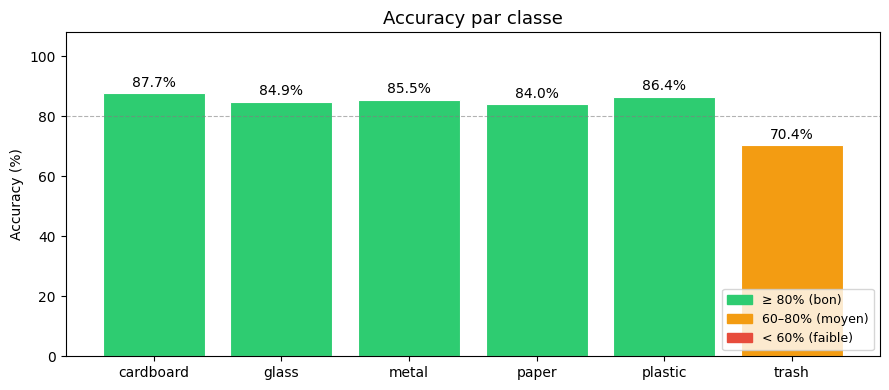

In [11]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

colors = ['#2ecc71' if a >= 0.80 else '#f39c12' if a >= 0.60 else '#e74c3c'
          for a in per_class_acc]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(class_names, per_class_acc * 100, color=colors, edgecolor='white', linewidth=0.8)

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.2,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=10)

ax.axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Seuil 80%')
ax.set_ylim(0, 108)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy par classe', fontsize=13)
ax.legend(fontsize=9)

patches = [
    mpatches.Patch(color='#2ecc71', label='≥ 80% (bon)'),
    mpatches.Patch(color='#f39c12', label='60–80% (moyen)'),
    mpatches.Patch(color='#e74c3c', label='< 60% (faible)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../model/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Visualisation des prédictions sur des images réelles

On affiche un échantillon d'images du test set avec :
- **Titre vert** = bonne prédiction
- **Titre rouge** = mauvaise prédiction (avec la vraie classe indiquée)
- La probabilité de confiance est affichée pour chaque prédiction.

C:\Users\GHADA\AppData\Local\Temp\ipykernel_4780\583268545.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\GHADA\AppData\Local\Temp\ipykernel_4780\583268545.py:37: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\GHADA\AppData\Local\Temp\ipykernel_4780\583268545.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('../model/sample_predictions.png', dpi=150, bbox_inches='tight')
C:\Users\GHADA\AppData\Local\Temp\ipykernel_4780\583268545.py:38: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('../model/sample_predictions.png', dpi=150, bbox_inches='tight')
c:\Users\GHADA\Desktop\smart-waste-classification\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print

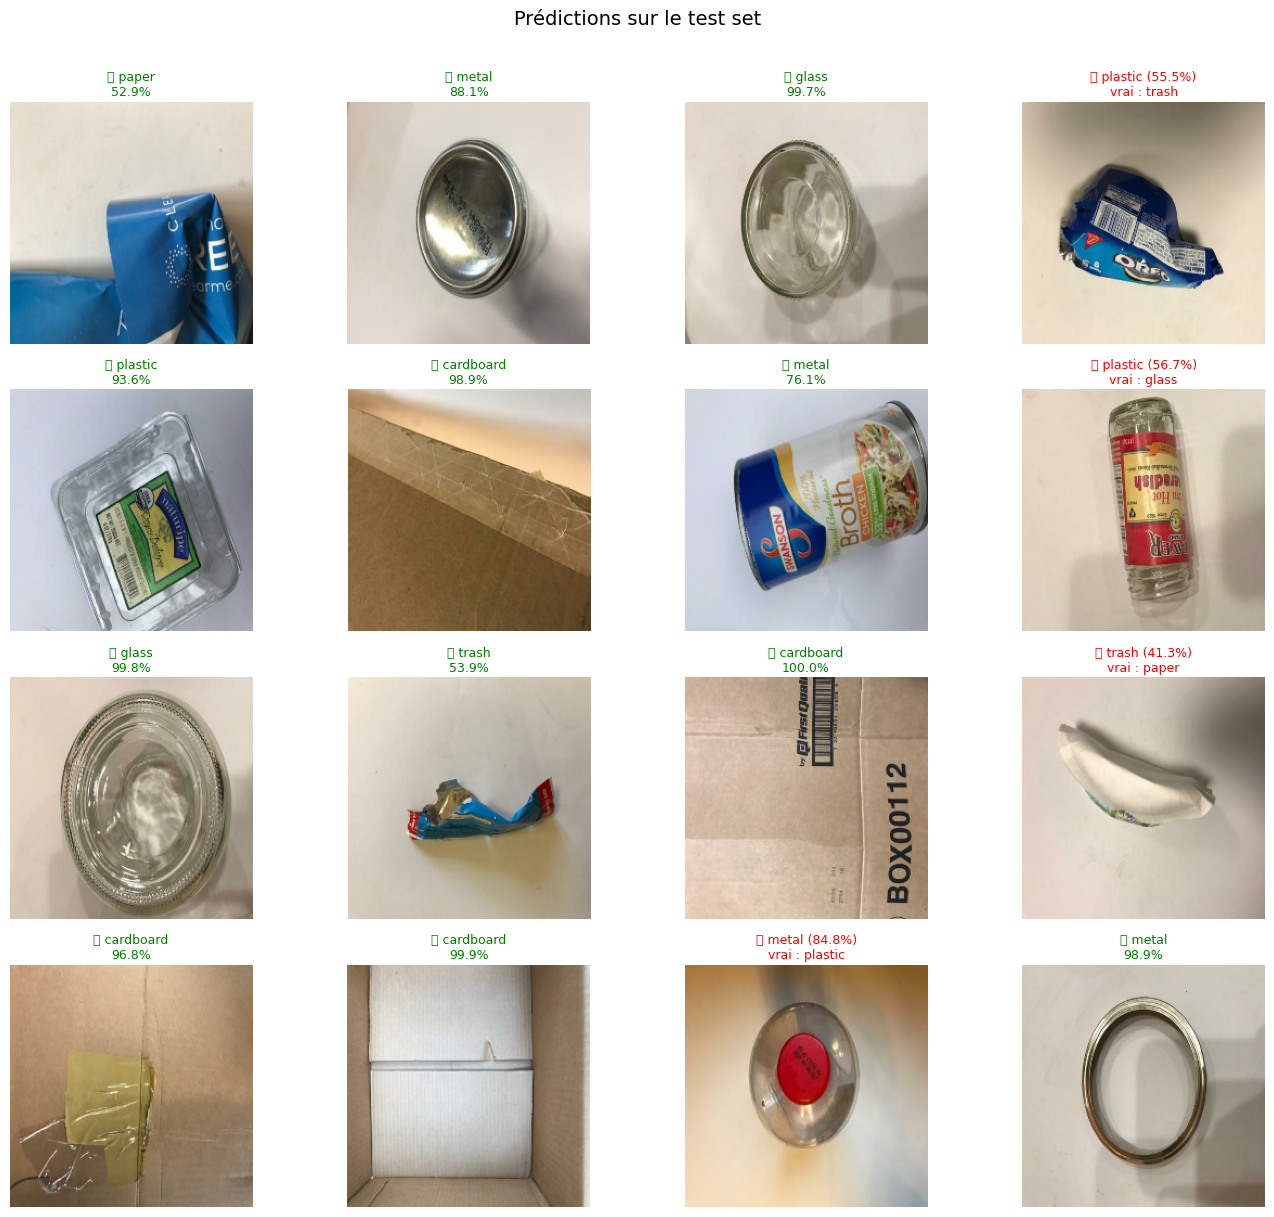

In [12]:
# Prendre un batch du test set pour la visualisation
test_images_batch, test_labels_batch = next(iter(test_dataset))

# Prédire ce batch
preds_batch = model.predict(test_images_batch, verbose=0)
pred_labels = np.argmax(preds_batch, axis=1)
confidences = np.max(preds_batch, axis=1)

# Afficher 16 images
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
axes = axes.flatten()

for i in range(min(16, len(test_images_batch))):
    img   = test_images_batch[i].numpy().astype('uint8')
    true  = int(test_labels_batch[i].numpy())
    pred  = pred_labels[i]
    conf  = confidences[i]
    correct = (true == pred)

    axes[i].imshow(img)
    axes[i].axis('off')

    if correct:
        title = f'✅ {class_names[pred]}\n{conf*100:.1f}%'
        color = 'green'
    else:
        title = f'❌ {class_names[pred]} ({conf*100:.1f}%)\nvrai : {class_names[true]}'
        color = 'red'

    axes[i].set_title(title, color=color, fontsize=9, pad=4)

# Masquer les axes vides
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Prédictions sur le test set', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../model/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Test sur une image personnalisée

Cette cellule permet de tester le modèle sur **n'importe quelle image** fournie par l'utilisateur.

Remplace `IMAGE_PATH` par le chemin vers ton image.

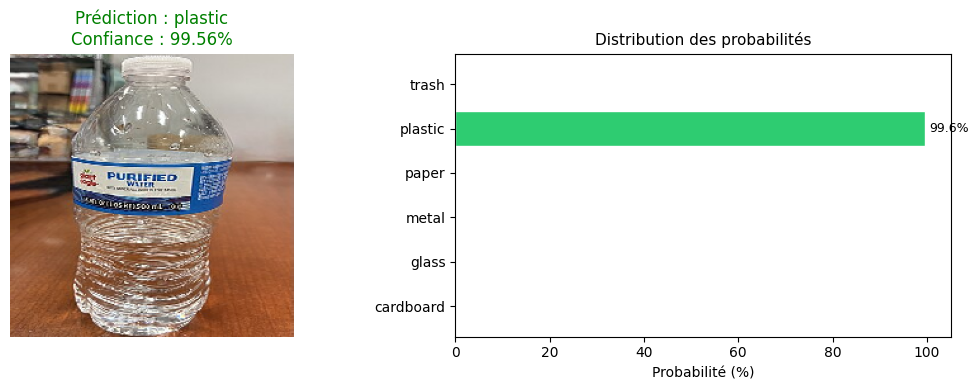


→ Classe prédite : plastic (99.56%)


In [13]:
# ── Paramètre à modifier ─────────────────────────────────────────────
IMAGE_PATH = '../dataset test/plastic/plastic1.jpg'  # ← remplace par ton image

# ── Chargement et preprocessing ──────────────────────────────────────
img_raw = tf.keras.utils.load_img(IMAGE_PATH, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img_raw)          # (224, 224, 3)
img_array = tf.expand_dims(img_array, axis=0)              # (1, 224, 224, 3)

# ── Prédiction ────────────────────────────────────────────────────────
preds = model.predict(img_array, verbose=0)[0]             # shape (6,)
pred_idx  = int(np.argmax(preds))
pred_class = class_names[pred_idx]
confidence = preds[pred_idx]

# ── Affichage ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Image
axes[0].imshow(img_raw)
axes[0].axis('off')
axes[0].set_title(f'Prédiction : {pred_class}\nConfiance : {confidence*100:.2f}%',
                  fontsize=12, color='green' if confidence > 0.7 else 'orange')

# Bar chart des probabilités
colors_bar = ['#2ecc71' if i == pred_idx else '#bdc3c7' for i in range(len(class_names))]
axes[1].barh(class_names, preds * 100, color=colors_bar, edgecolor='white')
axes[1].set_xlabel('Probabilité (%)')
axes[1].set_xlim(0, 105)
axes[1].set_title('Distribution des probabilités', fontsize=11)
for j, v in enumerate(preds):
    if v > 0.005:
        axes[1].text(v * 100 + 1, j, f'{v*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\n→ Classe prédite : {pred_class} ({confidence*100:.2f}%)')

---
## 13. Récapitulatif final

Ce bloc imprime un résumé complet de l'évaluation.

In [14]:
print('=' * 55)
print('      ÉVALUATION FINALE — WASTE CLASSIFIER')
print('=' * 55)
print(f'  Modèle            : waste_classifier.keras')
print(f'  Architecture      : MobileNetV2 + Transfer Learning')
print(f'  Nombre de classes : {len(class_names)}')
print(f'  Classes           : {class_names}')
print(f'  Images testées    : {len(true_classes)}')
print(f'  Test Accuracy     : {test_accuracy * 100:.2f}%')
print(f'  Test Loss         : {test_loss:.4f}')
print()
print('  Accuracy par classe :')
for i, (name, acc) in enumerate(zip(class_names, per_class_acc)):
    status = '✅' if acc >= 0.80 else '⚠️ ' if acc >= 0.60 else '❌'
    print(f'    {status} {name:12s} : {acc*100:.1f}%')
print('=' * 55)

      ÉVALUATION FINALE — WASTE CLASSIFIER
  Modèle            : waste_classifier.keras
  Architecture      : MobileNetV2 + Transfer Learning
  Nombre de classes : 6
  Classes           : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
  Images testées    : 413
  Test Accuracy     : 84.50%
  Test Loss         : 0.4885

  Accuracy par classe :
    ✅ cardboard    : 87.7%
    ✅ glass        : 84.9%
    ✅ metal        : 85.5%
    ✅ paper        : 84.0%
    ✅ plastic      : 86.4%
    ⚠️  trash        : 70.4%
